# Creación de modelos basados en máquinas de vector de soporte y random forest. 

El conjunto de datos se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/31/covertype

### Análisis descriptivo de los datos

In [ ]:
!pip3 install -U ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# se carga el dataset
covertype = fetch_ucirepo(id=31)

df = pd.DataFrame(data=covertype.data.features, columns=covertype.feature_names)
df['Cover_Type'] = covertype.data.targets

df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


¿Cuántas instancias de datos tiene el dataset?

In [ ]:
len(df)

581012

581011 instancias sin contar cabeceras

In [ ]:
cont_columns = [col for col in df.columns if df[col].nunique() > 7]
print(len(cont_columns))
#print(cont_columns)

10


Hay 10 variables continuas

Hay 44 variables categóricas binarias (0, 1).
Y Cover_Type con categorías del 1 al 7.

In [ ]:
cat_columns = [col for col in df.columns if df[col].nunique() <= 7]
print(len(cat_columns))

45


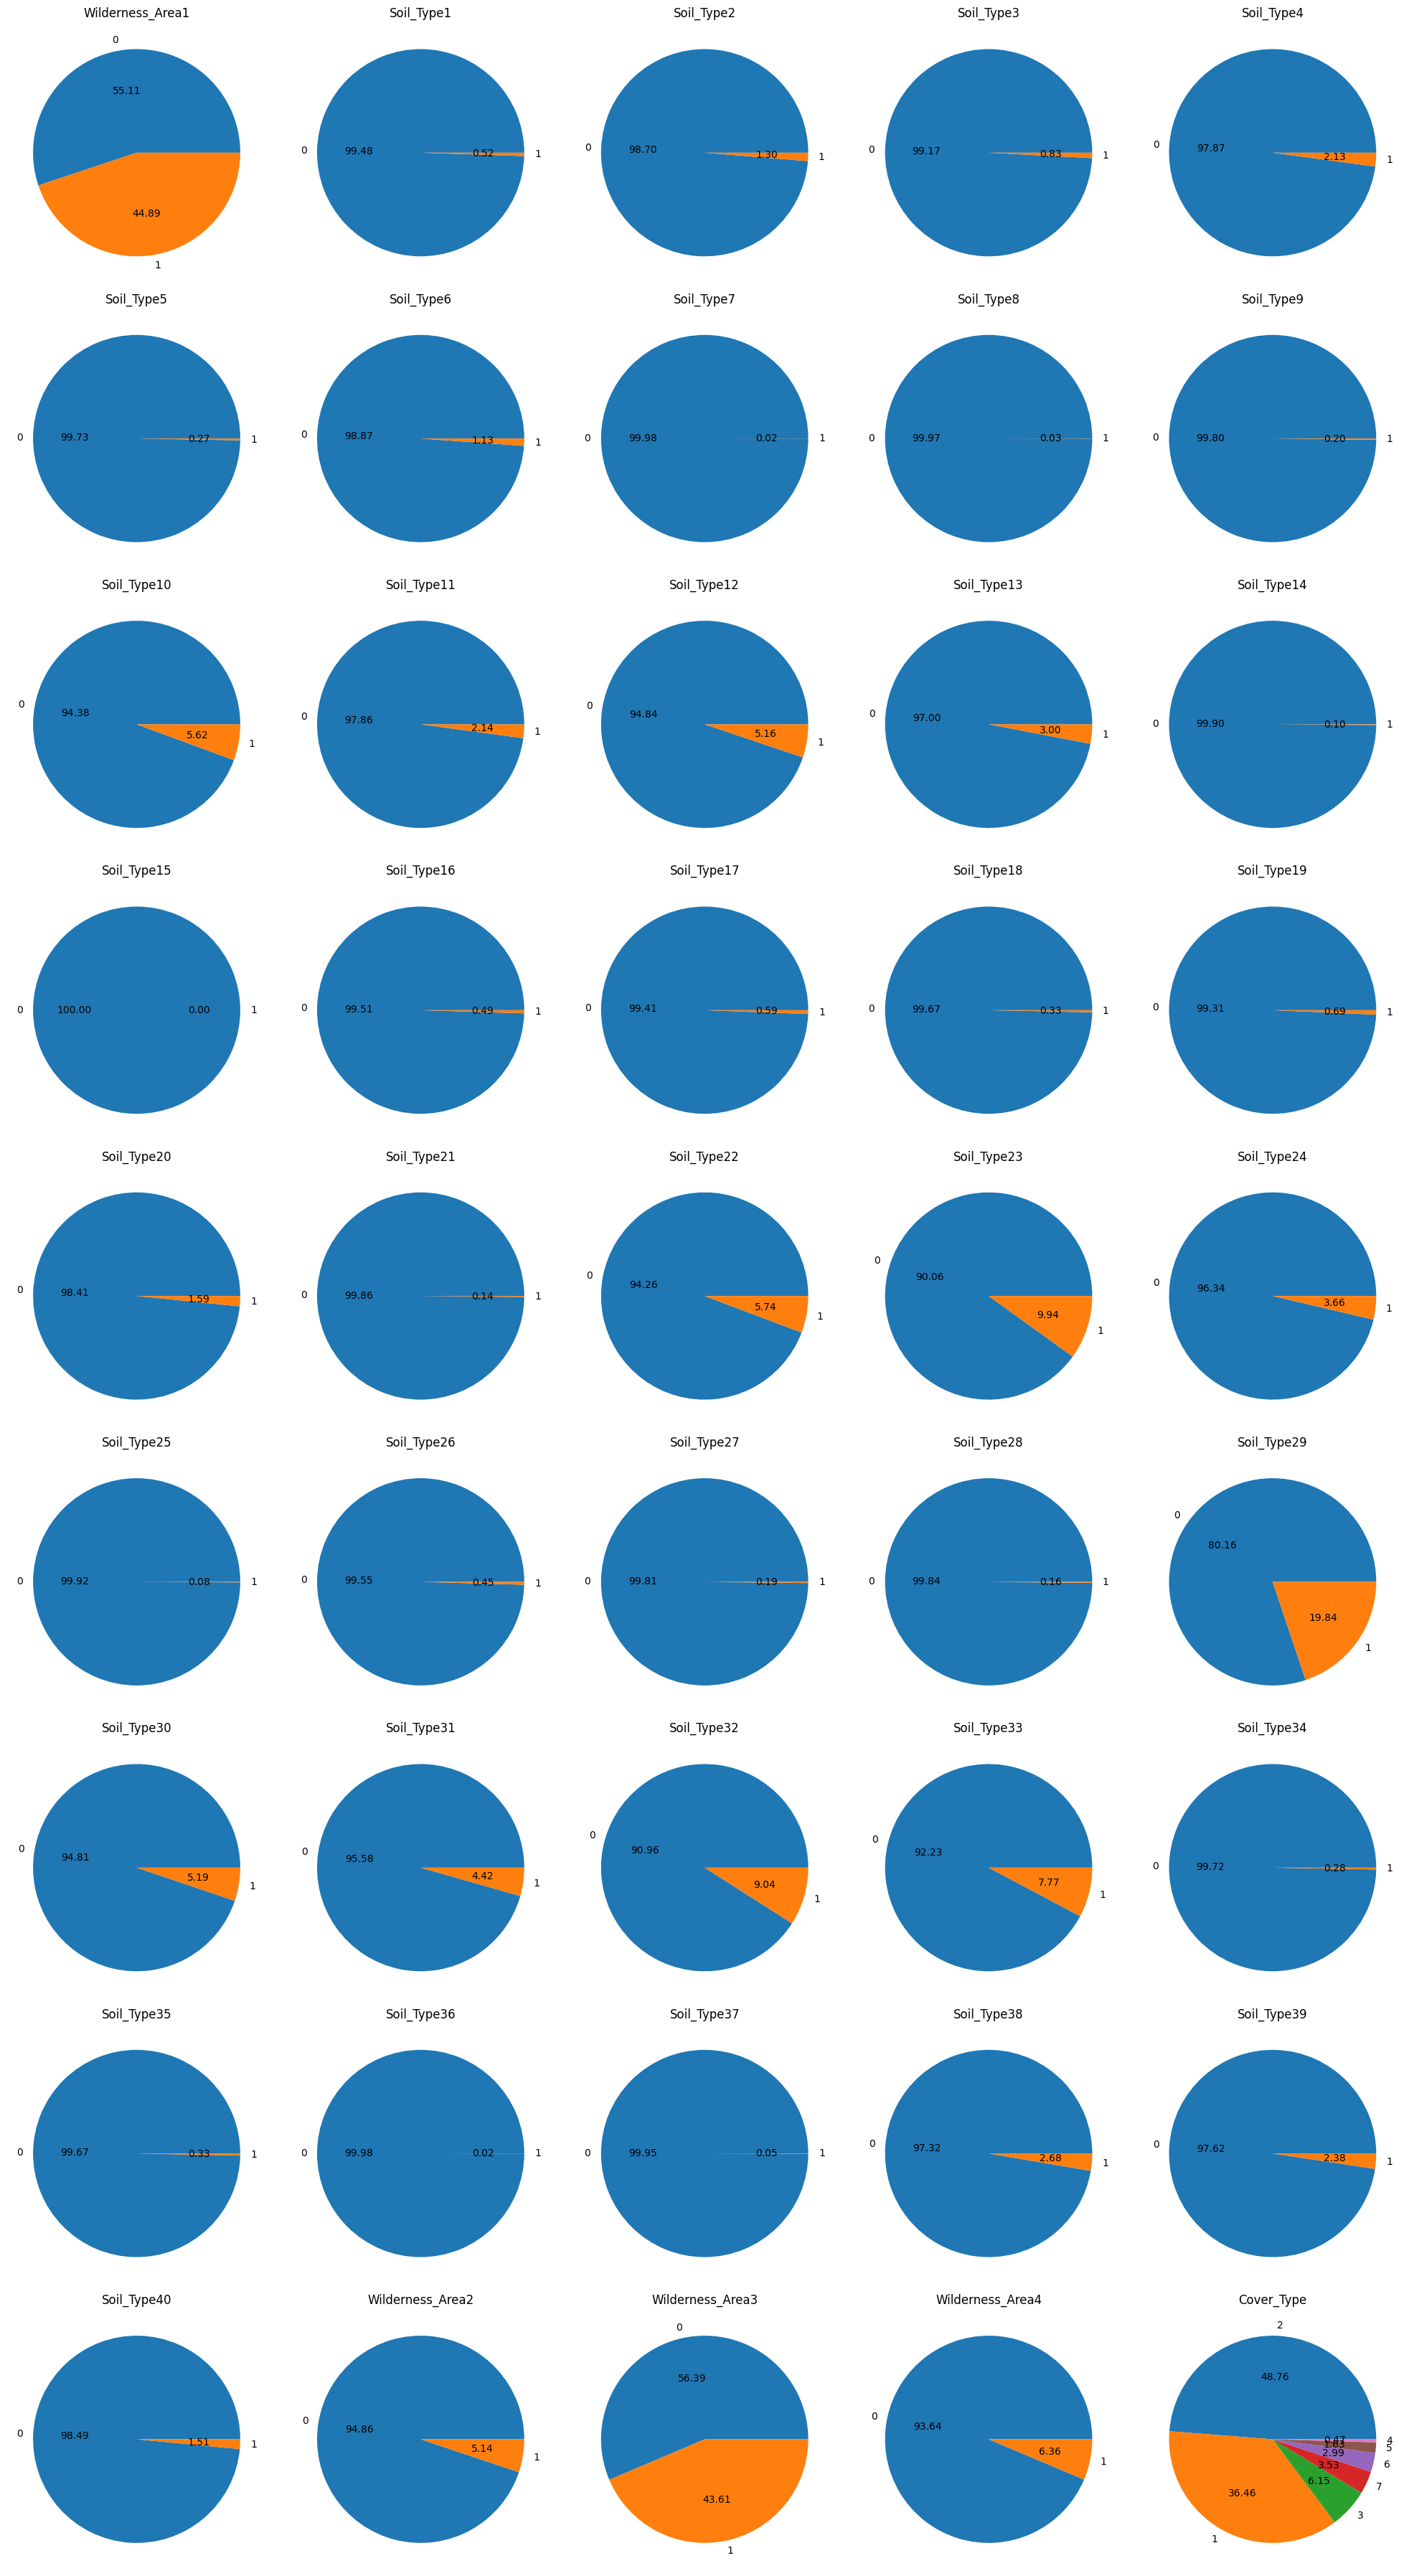

In [ ]:
import math

def plot_categories(data, columns):
  n_cols = 5
  n_rows = math.ceil(len(columns) / n_cols)

  fig_width = 4 * n_cols
  fig_height = 4 * n_rows

  fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))
  for i, col in enumerate(columns):
      row, col_idx = divmod(i, n_cols)
      ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]

      class_distribution = data[col].value_counts()
      class_distribution.plot(kind='pie', autopct='%.2f', ax=ax)
      ax.set_title(col)
      ax.set_ylabel('')

  plt.tight_layout()
  plt.show()

plot_categories(df, cat_columns)

Distribución etiquetas de clase de Cover_Type:
Cover_Type
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64


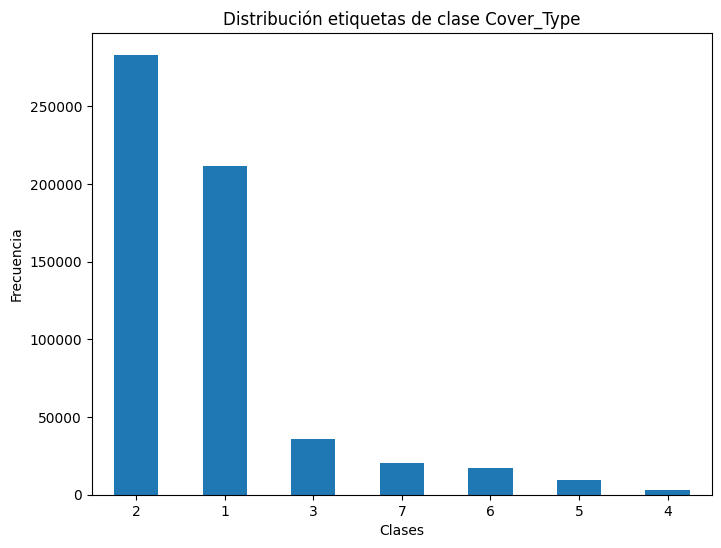

In [ ]:
class_distribution = df['Cover_Type'].value_counts()
print("Distribución etiquetas de clase de Cover_Type:")
print(class_distribution)

plt.figure(figsize=(8, 6))
class_distribution.plot(kind='bar')
plt.title("Distribución etiquetas de clase Cover_Type")
plt.xlabel("Clases")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

<Axes: ylabel='count'>

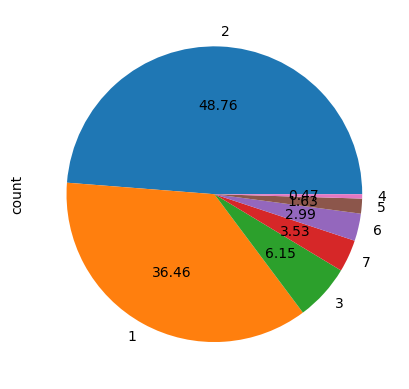

In [ ]:
df['Cover_Type'].value_counts().plot(kind='pie',autopct='%.2f',)

El dataset NO está balanceado, ya que, excepto _Wilderness\_Area3_, todas las variables categóricas tienen una clase dominante.

In [ ]:
df.isnull().sum().sum()

0

No hay valores nulos en el dataset.

No existe ninguna variable fuertemente correlacionada con la variable de clase _Cover\_Type_.
La variable más correlacionada es _Wilderness\_Area4_ con un 0.3232

In [ ]:
correlation_matrix = df.corr()

target_correlations = correlation_matrix['Cover_Type'].drop('Cover_Type')
most_correlated = target_correlations[target_correlations.abs() > 0.80]
print(most_correlated)

Series([], Name: Cover_Type, dtype: float64)


In [ ]:
most_correlated = target_correlations.abs().sort_values(ascending=False).head(4)
print(most_correlated)

Wilderness_Area4    0.323200
Elevation           0.269554
Soil_Type10         0.243876
Wilderness_Area1    0.203913
Name: Cover_Type, dtype: float64


Dibujamos los diagramas de dispersión por pares de variables, para ver si existe una correlación lineal entre alguna de las más correlacionadas (no es el caso). En la diagonal vemos la distribución de cada una de las variables por clases.

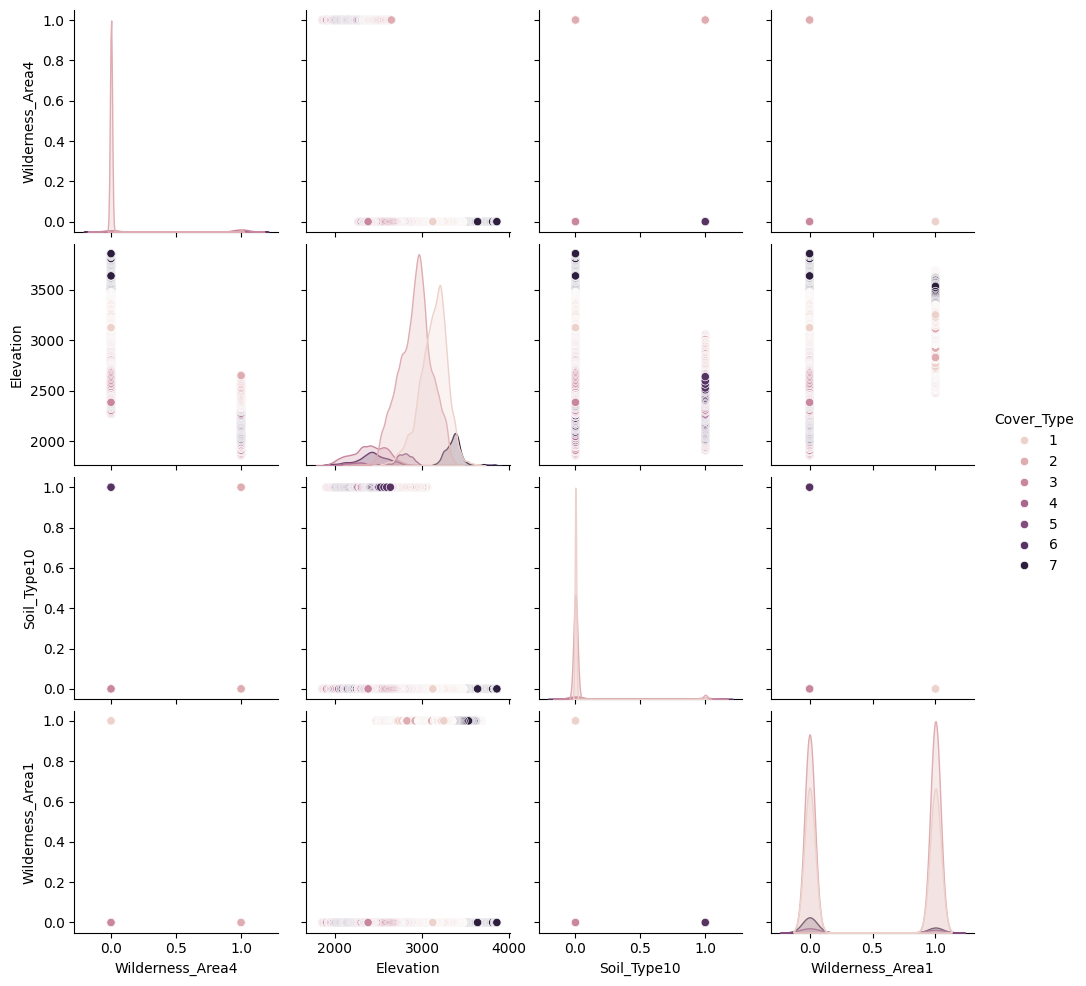

In [ ]:
# Tarda més de 10min
sns.pairplot(df, hue='Cover_Type', vars=most_correlated.index)

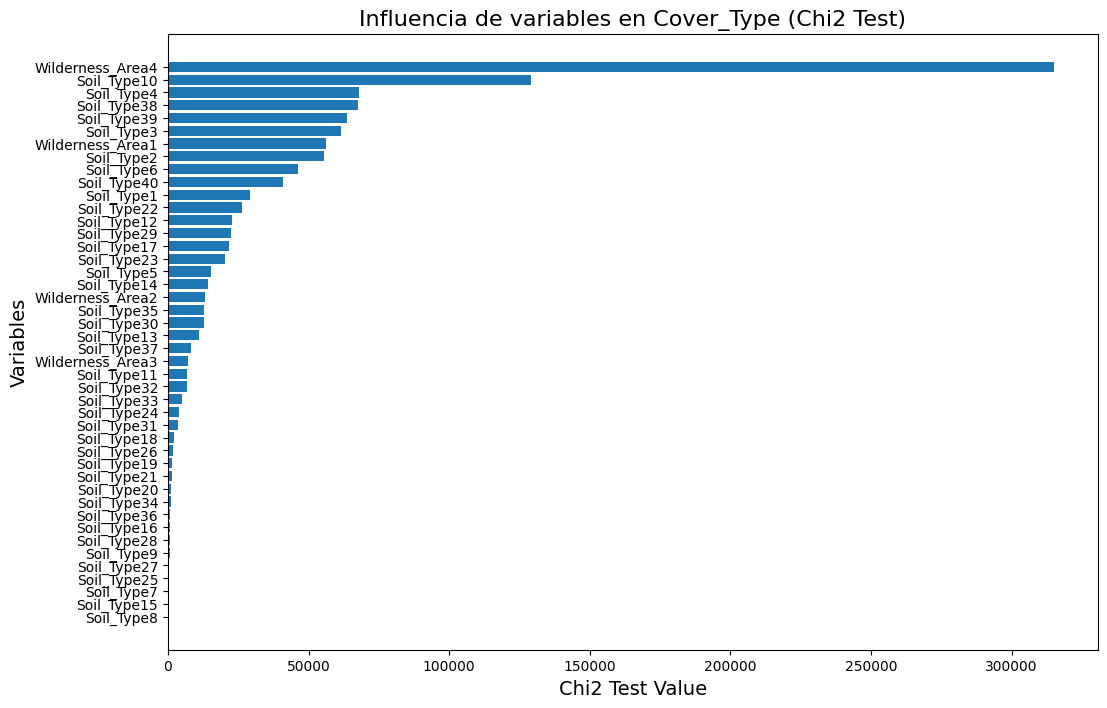

In [ ]:
# Calulamos el valor chi2 con cover_type, para las variables categoricas

from scipy.stats import chi2_contingency
test_results = []

for i, col in enumerate(cat_columns):
    contingency_table = pd.crosstab(df[col], df['Cover_Type'])
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    if col != 'Cover_Type':
        test_results.append({'column_name': col, 'chi2_test': chi2, 'p_value': p})

# Crear un DataFrame con los resultados
results_df = pd.DataFrame(test_results)
df_sorted = results_df.sort_values(by="chi2_test", ascending=False)

# Gráfico de barras
plt.figure(figsize=(12, 8))
plt.barh(df_sorted['column_name'], df_sorted['chi2_test'])
plt.gca().invert_yaxis()  # Invertir el eje y para que la variable más influyente esté arriba
plt.title('Influencia de variables en Cover_Type (Chi2 Test)', fontsize=16)
plt.xlabel('Chi2 Test Value', fontsize=14)
plt.ylabel('Variables', fontsize=14)
plt.show()

In [ ]:
# Mostramos una comparativa entre el valor chi2 y la matriz de correlacion
threshold = results_df.loc[results_df['column_name'] == 'Soil_Type40', 'chi2_test'].values[0]
filtered_results = results_df[results_df['chi2_test'] >= threshold].set_index('column_name')

filtered_columns = list(filtered_results.index) + ['Cover_Type']
filtered_df = df[filtered_columns]
filtered_correlation_matrix = filtered_df.corr()

joined_results = filtered_results.join(filtered_correlation_matrix[['Cover_Type']], how='inner')
sorted_results = joined_results.reindex(joined_results['Cover_Type'].abs().sort_values(ascending=False).index)

display(sorted_results.head(3))

,chi2_test,p_value,Cover_Type
Wilderness_Area4,314948.432574,0.0,0.323200
Soil_Type10,129161.457207,0.0,0.243876
Wilderness_Area1,56245.464609,0.0,-0.203913


Para determinar las variables más influyentes sobre Cover_Type, hemos utilizado dos métodos distintos: la matriz de correlación y la prueba chi-cuadrado (chi² test). A continuación, se explican los resultados obtenidos con cada enfoque:

La matriz de correlación mide la relación lineal entre las variables. Al analizar las correlaciones (tanto directas como inversas) entre las variables del dataset y Cover_Type, hemos identificado las tres variables más influyentes: Wilderness_Area4, Soil_Type10, Wilderness_Area1

El test chi² evalúa si existe una asociación estadísticamente significativa entre dos variables categóricas. Usando este método, las tres variables más influyentes en relación con Cover_Type han sido: Wilderness_Area4, Soil_Type10,Soil_Type4

La principal diferencia entre ambos métodos es la posición de Wilderness_Area1 y Soil_Type4. Con la matriz de correlación, Wilderness_Area1 resulta más influyente que Soil_Type4 debido a su relación lineal con Cover_Type.
Con el test chi², Soil_Type4 supera a Wilderness_Area1 en importancia, probablemente debido a la fuerza de su asociación categórica con Cover_Type.

Ambos métodos aportan perspectivas complementarias que enriquecen el análisis de la influencia de las variables sobre la variable objetivo.

Para un problema de clasificación como en el que nos encontramos, podríamos evaluar la ganancia de información o la reducción de la impureza de Gini.

Si calculamos la "Ganancia de información" (o reducción de la entropía) como medida de selección de variables. Las 3 variables más influyentes serían _Elevation_, _Wilderness\_Area4_ y _Wilderness\_Area1_.

In [ ]:
from sklearn.feature_selection import mutual_info_classif

X, y = df.drop('Cover_Type',axis=1), df['Cover_Type']

# Això triga uns 5 minuts en executar
mutual_info = mutual_info_classif(X, y, random_state=0)
mutual_info_series = pd.Series(mutual_info, index=X.columns).sort_values(ascending=False)

top_3_features = mutual_info_series.head(3)
print(top_3_features)

Elevation           0.458050
Wilderness_Area4    0.146825
Wilderness_Area1    0.104763
dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
X, y = df.drop('Cover_Type',axis=1), df['Cover_Type']
# Crear y entrenar un modelo Random Forest
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, criterion="gini")
rf_model.fit(X, y)

RandomForestClassifier(n_estimators=50, random_state=42)

Top 3 características más influyentes según el índice Gini:
Elevation                             0.243326
Horizontal_Distance_To_Roadways       0.118267
Horizontal_Distance_To_Fire_Points    0.112735
dtype: float64


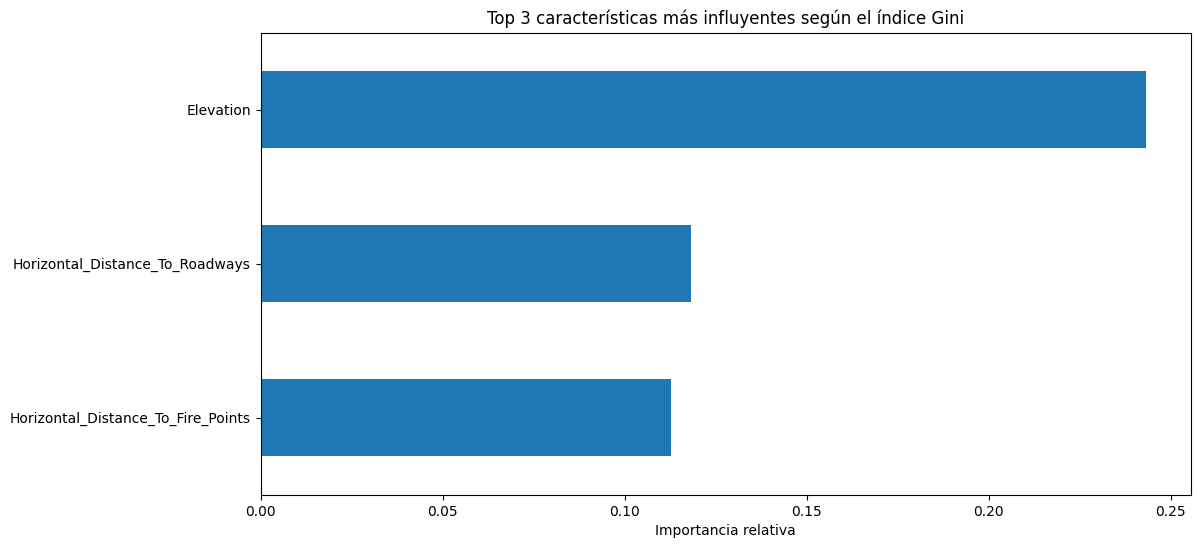

In [ ]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
# Mostrar las 3 características más influyentes
top_3_features_gini = feature_importances.head(3)
print("Top 3 características más influyentes según el índice Gini:")
print(top_3_features_gini)

plt.figure(figsize=(12, 6))
top_3_features_gini.sort_values(ascending=True).plot(kind='barh')
plt.title("Top 3 características más influyentes según el índice Gini")
plt.xlabel("Importancia relativa")
plt.show()

### df = balanced_dfs

Para mejorar el rendimiento del modelo y evitar que clases mayoritarias dominen el proceso de aprendizaje, se ha realizado un proceso de reducción de la cardinalidad y balanceo en el dataset de entrenamiento.

Este enfoque tiene como objetivo:

- La cardinalidad elevada en los datos de entrenamiento puede incrementar la complejidad del modelo y afectar su capacidad de generalización. Al seleccionar una porción representativa del dataset original, se reduce la cantidad de datos sin perder su diversidad.
Balancear las clases:

- Dado que las clases influyentes en el dataset estan desbalanceadas, se ha creado un subconjunto de datos `balanced_dfs` donde todas las clases están representadas de forma más equilibrada.

Debido a que muchas de las características de Soil_Type son mutuamente excluyentes, mantener la representación completa de todas estas características impedía una reducción eficiente del conjunto de datos. Por ello, se seleccionaron únicamente aquellas características con mayor relevancia según el análisis del test chi². Este enfoque permitió reducir significativamente la cardinalidad de los datos, optimizando el modelo sin perder información clave.

In [23]:
balanced_dfs = []
balanced_labels = []

tmp_df = df.copy()

min_class_size = int(100000 / len(filtered_columns))
for col in filtered_columns:
    class_df = tmp_df[tmp_df[col] == 1]
    population = len(class_df)
    sampled_df = class_df.sample(min(min_class_size, population), random_state=42)
    balanced_dfs.append(sampled_df)
    balanced_labels.extend([col] * len(sampled_df))
    # Eliminar las filas seleccionadas del DataFrame original
    tmp_df = tmp_df.drop(sampled_df.index)

# Combinar el DataFrame balanceado
balanced_dataset = pd.concat(balanced_dfs)
balanced_labels = pd.Series(balanced_labels)

print(f"Dataset shape: {balanced_dataset.shape}, Labels shape: {balanced_labels.shape}")

Dataset shape: (91144, 55), Labels shape: (91144,)


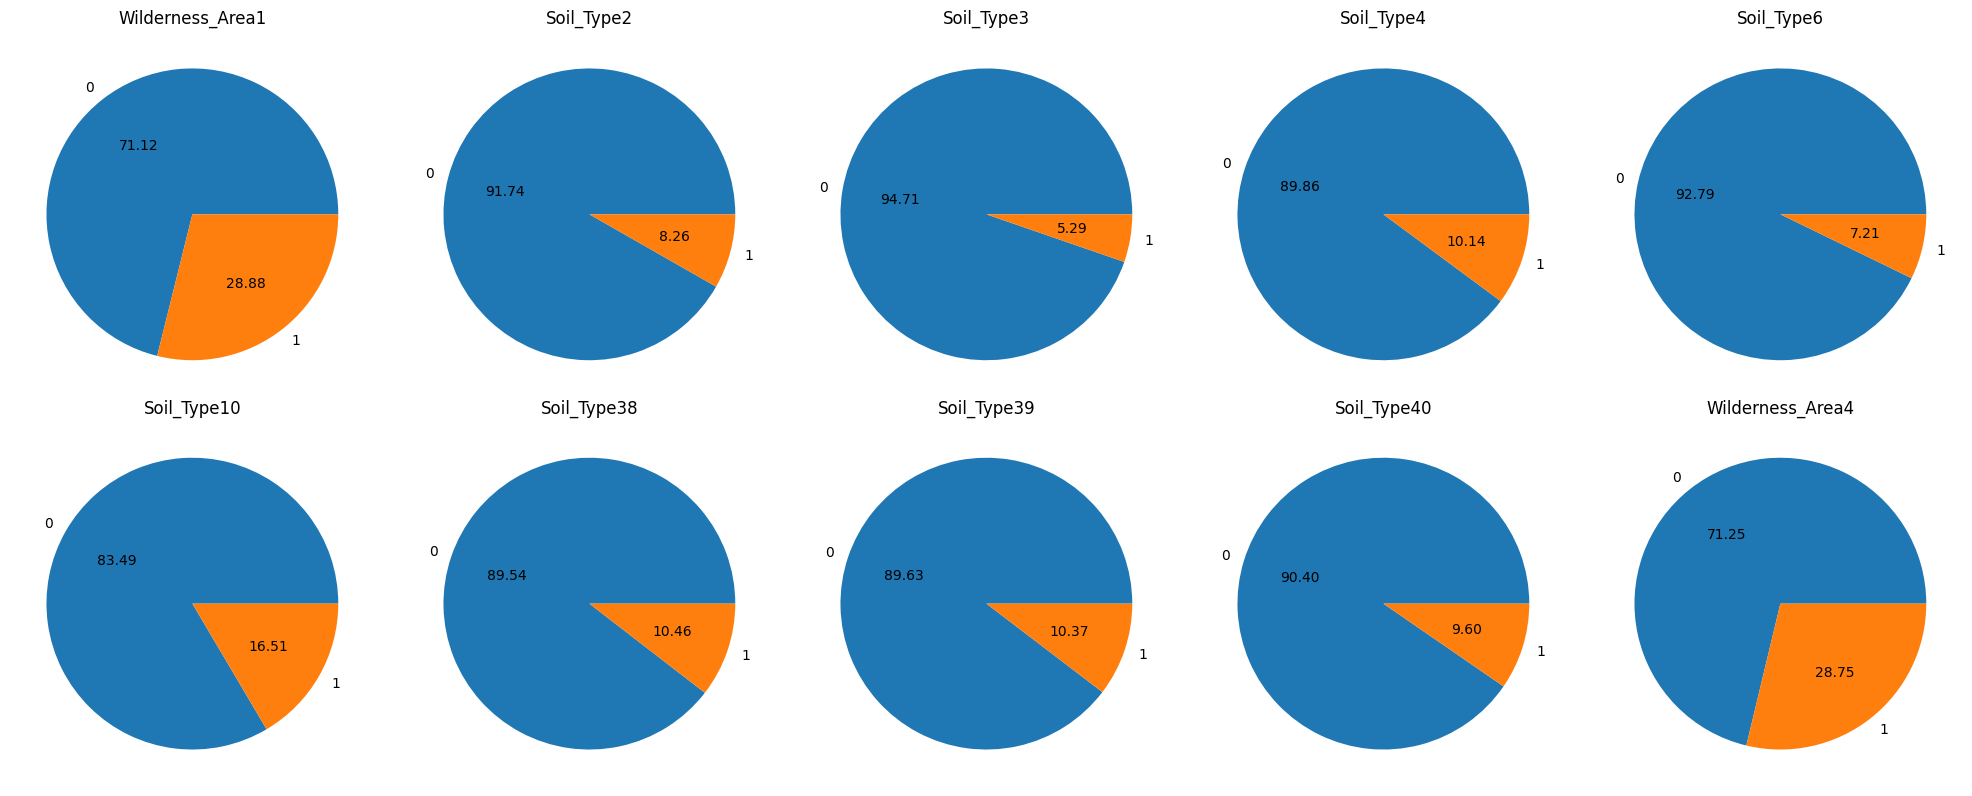

91144

In [24]:
filtered_columns_without_cover_type = [col for col in filtered_columns if col != 'Cover_Type']
plot_categories(balanced_dataset, filtered_columns_without_cover_type)
len(balanced_dataset)

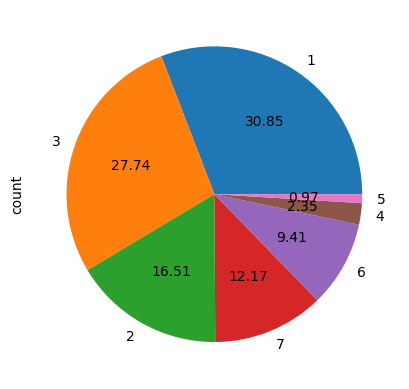

In [28]:
balanced_dataset['Cover_Type'].value_counts().plot(kind='pie',autopct='%.2f',)
plt.show()

In [30]:
# Separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

X, y = balanced_dataset.drop('Cover_Type',axis=1), balanced_dataset['Cover_Type']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=1)

### Clasificación

**Random Forest**

Librería https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html para resolver el problema de clasificación.

- **n_estimators**: Número de árboles en el bosque (cuantos más árboles, mayor capacidad del modelo pero más tiempo de entrenamiento).
- **criterion**: Función para medir la calidad de una división en cada árbol (valores aceptados: gini, log_loss, entropy).
- **max_depth**: Profundidad máxima del árbol (controla el crecimiento de los árboles para evitar overfitting).
- **min_samples_split**: Número mínimo de muestras requeridas para dividir un nodo intermedio.
- **min_samples_leaf**: Número mínimo de muestras que debe tener un nodo hoja.
- **max_features**: Número máximo de características consideradas para buscar la mejor división en cada nodo.

_class_weight_ sirve para ajustar los pesos asociados a cada clase cuando tenemos un dataset desbalanceado, donde alguna clase tiene significativamente más muestras que otras.

Por ejemplo, en un problema de clasificación binaria con clases desbalanceadas, si se asigna un mayor peso a la clase minoritaria mediante _class_weight_, la función de pérdida reflejará una penalización más significativa por errores en esa clase, incentivando al modelo a mejorar su rendimiento en la misma.

No es necesario normalizar los datos para entrenar un clasificador de Random Forest, ya que se basa en árboles de decisión, los cuales dividen los datos en nodos basándose en umbrales de las características. Los valores de las características se comparan directamente con los umbrales en cada nodo, por lo que la escala de las características no afecta la construcción del modelo.

Las decisiones en Random Forest no dependen de la magnitud de las características, ya que sólo evalúan comparaciones relativas (<,>). Por ejemplo, una característica en el rango [0, 1] y otra en el rango [0, 1000] no tienen un impacto desproporcionado.



Entrena un conjunto de modelos de Random Forest que utilicen todas las variables del dataset, con 5, 10, 20, 50 y 100 árboles. El criterio para realizar las particiones debe ser Gini-index, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

_Nota: el entrenamiento puede tardar entre 3 y 15 minutos en función de las características del equipo._

In [31]:
# numero de árboles: 5, 10, 20, 50 y 100
from sklearn.ensemble import RandomForestClassifier

n_arboles = {5, 10, 20, 50, 100}
particion = 'gini'
max_depth = 10
min_samples_split = 10
min_samples_leaf = 2
max_feature = None

randomForest = [RandomForestClassifier(n_estimators = i, criterion= particion,
                                       max_depth = max_depth, min_samples_split = min_samples_split,
                                      min_samples_leaf = min_samples_leaf, max_features =None) for i in n_arboles]

In [32]:
from tqdm import tqdm

for clf in tqdm(randomForest, desc="Entrenando modelos"):
    clf.fit(X_train, y_train)

Entrenando modelos: 100%|██████████| 5/5 [01:11<00:00, 14.24s/it]


Visualiza la matriz de confusión del modelo entrenado con 20 árboles.

In [ ]:
## PON AQUÍ TU CÓDIGO

[[20853   800    32     0     8     1   843]
 [ 1161  9484   865     0    14   372   125]
 [    0   317 19040    71     1   736     0]
 [    0     0   407  1292     0    17     0]
 [   11   140   128     0   415     3     0]
 [    0   200  2628    25     4  4073     0]
 [  706     5     0     0     0     0  8138]]


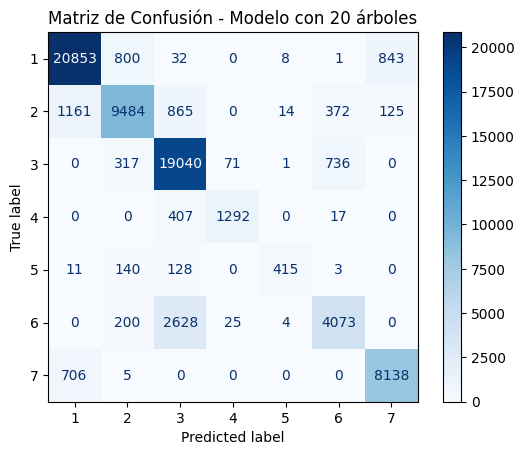

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for clf in randomForest:
    if clf.n_estimators == 20:
        y_pred_20_trees = clf.predict(X_train)

        cm = confusion_matrix(y_train, y_pred_20_trees, labels=clf.classes_)
        print(cm)

        correct_predictions_20_trees = cm.diagonal().sum()

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
        disp.plot(cmap=plt.cm.Blues)

        plt.title("Matriz de Confusión - Modelo con 20 árboles")
        plt.show()

In [34]:
print(f"Ejemplos bien clasificados: {cm.diagonal().sum()}")

Ejemplos bien clasificados: 63295


En base a la matriz de confusión podemos entender cómo el modelo está clasificando cada una de las 7 categorías de la propiedad **_Cover_Type_**.

Las filas de la matriz representan las clases reales y las columnas las clases predichas por el modelo.  
La diagonal nos muestra el número de ejemplos clasificados correctamente para cada clase/categoría.

Así, podemos ver que, en términos absolutos, las **clases 1, 3** son las que mayor número de ejemplos clasifican correctamente (20.853 y 19.040 respectivamente).

Se puede también apreciar una tendencia a la confusión entre las clases 1 y 2.

- 1.161 ejemplos de la clase 2 clasificados como clase 1.
- 800 ejemplos de la clase 1 clasificados como clase 2.

La **clase 3** clasifica correctamente la mayoría de los ejemplos (19.040), aunque tiene errores significativos hacia la clase 6 (736) y, en menor medida, hacia la clase 2 (317).

La **clase 4** muestra tendencia a confusión hacia la clase 3 (407 ejemplos).

Las **clases 5 y 6** son las que peor rendimiento muestran. La clase 5 es la que menos ejemplos clasifica en términos absolutos (415), con los errores más frecuentes hacia la clases 2 y 3. Y la clase 6 muestra una fuerte tendencia a la confusión hacia la clase 3 (2.628 ejemplos).

La **clase 7** clasifica correctamente un número alto de ejemplos (8.138), aunque muestra una clara confusión hacia la clase 1 (706 ejemplos erróneamente clasificados).

Porcentualmente, las clases que mejor clasifican son:

- Clase 1 (**93.51%**)
- Clase 7 (**91.98%**)
- Clase 3 (**90.76%**)
- Clase 2 (**82.11%**)
- Clase 4 (**75.94%**)
- Clase 6 (**59.20%**)
- Clase 5 (**54.98%**)



In [41]:
from sklearn.metrics import precision_score

resultados = []
for clf in randomForest:
    accuracy_test = clf.score(X_test, y_test)
    precision_test = precision_score(y_test, y_pred, average="macro")

    resultados.append({
        'n_trees': clf.n_estimators,
        'accuracy_test': accuracy_test,
        'precision_test': precision_test
    })

resultados_df = pd.DataFrame(resultados)
resultados_df = resultados_df.sort_values(by='accuracy_test', ascending=False)

print(resultados_df)

   n_trees  accuracy_test  precision_test
0       50       0.855066        0.849411
1      100       0.854353        0.849411
3       20       0.849909        0.849411
4       10       0.847167        0.849411
2        5       0.842888        0.849411


Podemos calcular la accuracy y precision de los modelos para cada clase y calcular el promedio, para ello usaremos los métodos _score_ y _precision\_score_ con la opción _"macro"_ para el argumento _average_ de éste último.

El modelo con la mejor accuracy y mejor precision, para el conjunto de test, debería asegurar un buen desempeño en todas las clases, incluso con un dataset desbalanceado. En este caso el modelo Random Forest con 50 árboles es el que obtiene un mejor accuracy score: 0.855066

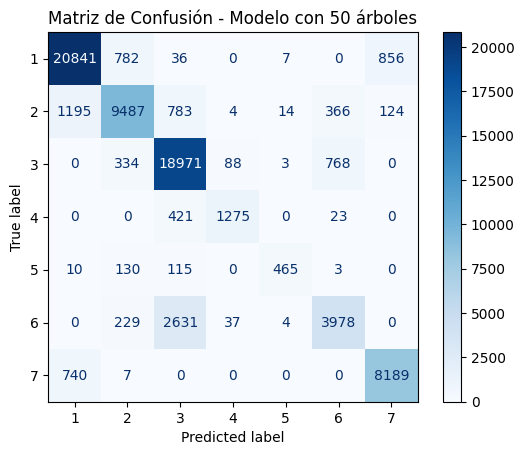

Correctamente clasificados = 63206
Clasificados erróneamente = 9710


In [73]:
for clf in randomForest:
    if clf.n_estimators == 50:
        y_pred_50_trees = clf.predict(X_test)

        cm = confusion_matrix(y_test, y_pred_50_trees, labels=clf.classes_)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
        disp.plot(cmap=plt.cm.Blues)

        plt.title("Matriz de Confusión - Modelo con 50 árboles")
        plt.show()

correct = cm.diagonal().sum()
print(f"Correctamente clasificados = {correct}")
print(f"Clasificados erróneamente = {len(X_test) - correct}")

Clasifica todas las clases de forma bastante similar, excepto las clases 5 y 6 que tienen una capacidad predictiva significativamente menor.

In [50]:
from sklearn.metrics import classification_report

def show_metrics_per_class(y_predictions):
  report = classification_report(y_test, y_predictions, output_dict=True)
  report_df = pd.DataFrame(report).transpose()

  print(report_df)

  class_metrics = report_df.iloc[:-3][["precision", "recall", "f1-score"]]

  best_class = class_metrics["f1-score"].idxmax()
  worst_class = class_metrics["f1-score"].idxmin()

  print("\n")
  print(f"- Clase con mejor rendimiento: {best_class} (F1-Score: {class_metrics.loc[best_class, 'f1-score']:.4f})")
  print(f"- Clase con peor rendimiento: {worst_class} (F1-Score: {class_metrics.loc[worst_class, 'f1-score']:.4f})")
  print("\n")

  class_metrics.plot(kind='bar', figsize=(12, 6))
  plt.title("Precisión, Recall y F1-score por clase")
  plt.xlabel("Clases")
  plt.xticks(rotation=0)
  plt.legend(title="Métricas")
  plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
  plt.show()

              precision    recall  f1-score       support
1              0.899877  0.915203  0.907475   5578.000000
2              0.837955  0.769256  0.802137   3025.000000
3              0.826826  0.930482  0.875597   5121.000000
4              0.874644  0.724057  0.792258    424.000000
5              0.942623  0.614973  0.744337    187.000000
6              0.743671  0.570388  0.645604   1648.000000
7              0.889864  0.902939  0.896354   2246.000000
accuracy       0.855066  0.855066  0.855066      0.855066
macro avg      0.859351  0.775328  0.809109  18229.000000
weighted avg   0.853575  0.855066  0.851641  18229.000000


- Clase con mejor rendimiento: 1 (F1-Score: 0.9075)
- Clase con peor rendimiento: 6 (F1-Score: 0.6456)




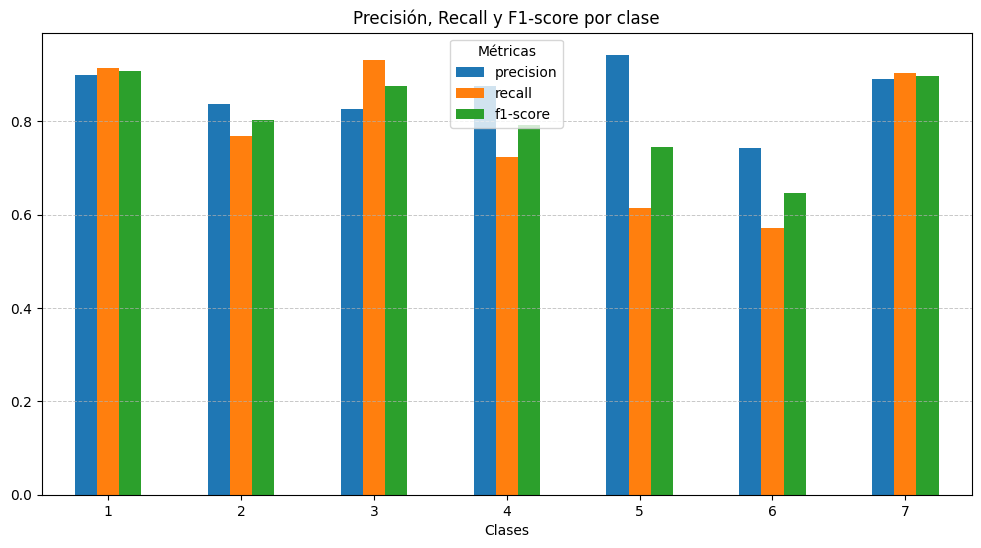

In [52]:
show_metrics_per_class(y_pred_50_trees)

**Support Vector Machine**

In [53]:
# Importamos las librerías para utilizar las máquinas de vector de soportes.
# Utilizaremos la librería svm:

from sklearn import svm

#Cargamos también las librerías para hacer la matriz de confusión y la cross validation:

from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold

Para la implementación del modelo de clasificación de SVM usaremos la clase Support Vector Classifier de sklearn, https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

El algoritmo de SVM necesita ajustar una serie de hiperparámetros para realizar las clasificaciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de clasificación, nos tenemos que preocupar de los siguientes hiperparámetros:
- C
- kernel
- degree
- gamma

Indica qué son cada uno de estos hiperparámetros

### Parámetros del SVC
- `C`: controla el equilibrio entre maximizar el margen del clasificador y minimizar el error de clasificación en los datos de entrenamiento. Es un hiperparámetro clave que afecta el rendimiento del modelo.
  - `C` grande (alta penalización para errores). El modelo intentará clasificar correctamente tantos puntos como sea posible en el conjunto de entrenamiento. Es más probable que el modelo se ajuste a los datos (sobreajuste).
  - `C` pequeño (baja penalización para errores). El modelo acepta un margen más amplio. Fomenta la generalización del modelo.
- `kernel`: define la función de núcleo que se utiliza para transformar los datos de entrada en un espacio de mayor dimensión. Este espacio transformado permite que el SVM encuentre un hiperplano que separe los datos de manera más efectiva, incluso cuando no son linealmente separables en el espacio original. Acepta distintos valores de entrada `linear`, `poly`, `rbf`, `sigmoid`. Siendo `rbf` la más utilizada porque funciona bien en la mayoría de los casos con datos no lineales.
- `degree`: se utiliza para especificar el grado del polinomio cuando el núcleo (kernel) seleccionado es poly (polinomial).
  - `Grados bajos`: Capturan relaciones menos complejas entre las características.
  - `Grados altos`: Pueden modelar relaciones más complejas, pero también aumentan el riesgo de sobreajuste.
- `gamma`: controla la influencia de un solo punto de datos en el modelo cuando se utiliza un núcleo que involucra distancias no lineales, como `rbf`, `polynomial`, o `sigmoid`.
  - `Valores grandes`: El modelo intenta capturar patrones muy específicos y puede sobreajustarse a los datos de entrenamiento.
  - `Valores pequeños`: El modelo intenta capturar patrones globales.


- `decision_function_shape`: controla la forma en que se calcula la función de decisión para problemas de clasificación multiclase. Especifica cómo se combinan los resultados de estos clasificadores para tomar decisiones en problemas con más de dos clases. Puede tomar los siguientes valores:
  - `ovo`: Compara cada par de clases en el conjunto de datos. Es más preciso en problemas multiclase y puede ser más costoso computacionalmente.
  - `ovr`: Considera cada clase frente a todas las demás. Es más eficiente en términos computacionales, pero puede ser menos preciso.

#### ¿Para qué puede ser útil?
- `Optimización computacional`: `ovo` ser costoso en términos de tiempo y memoria para problemas con muchas clases.
- `Interpretación de resultados`: `ovr` simplifica la salida del modelo i la interpretación del mismo.

In [ ]:
#df = df.head(100000)

In [54]:
# Con el nuevo número de instancias, separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

X, y = balanced_dataset.drop('Cover_Type',axis=1), balanced_dataset['Cover_Type']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.8, random_state=1)

Antes de entrenar el modelo, normalizaremos los datos, ya que el algoritmo de SVM es sensible a la escala de las características, especialmente cuando se utilizan kernels no lineales como **rbf**.

In [55]:
from sklearn.preprocessing import StandardScaler
from pandas import DataFrame

scaler = StandardScaler()

X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

df_norm = pd.DataFrame(X_train_norm)
df_norm.head()

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
0,-0.729681,-0.931053,-0.349319,0.018183,0.761536,-0.708138,0.712217,-0.404791,-0.707206,-0.251121,...,-0.007407,-0.025666,0.0,-0.010475,-0.339014,-0.342124,-0.316952,-0.236173,1.292582,-0.637304
1,-0.996526,-0.725904,0.957690,-0.967272,-0.646051,-0.790651,1.179712,-1.359277,-1.873478,-0.368125,...,-0.007407,-0.025666,0.0,-0.010475,-0.339014,-0.342124,-0.316952,-0.236173,1.292582,-0.637304
2,1.606897,1.236390,-1.537510,-0.000410,-0.070908,-0.187616,0.026558,0.723239,0.571207,-0.247464,...,-0.007407,-0.025666,0.0,-0.010475,-0.339014,-0.342124,3.155048,4.234188,-0.773645,-0.637304
3,0.203157,-0.315606,-0.705776,0.041425,-0.706593,1.426896,0.930382,0.593081,-0.348354,2.444546,...,-0.007407,-0.025666,0.0,-0.010475,-0.339014,-0.342124,-0.316952,-0.236173,-0.773645,-0.637304
4,1.212235,0.317680,-0.824595,1.696246,1.609115,-0.032216,0.244723,1.243867,0.593635,-0.156055,...,-0.007407,-0.025666,0.0,-0.010475,2.949730,-0.342124,-0.316952,-0.236173,1.292582,-0.637304


Entrena un conjunto de modelos de SVM que utilicen todas las variables del dataset, con C = 0.1 hasta 1000 con cinco valores diferentes; kernel radial, y gamma con valor scale.

In [56]:
from sklearn.svm import SVC

C = [0.1, 1, 10, 100, 1000]
kernel = 'rbf'
gamma = 'scale'

svc = [SVC(C=i, kernel=kernel, gamma=gamma) for i in C]
svc

[SVC(C=0.1), SVC(C=1), SVC(C=10), SVC(C=100), SVC(C=1000)]

In [57]:
from tqdm import tqdm

for model in tqdm(svc, desc="Entrenando modelos"):
    model.fit(X_train_norm, y_train)

Entrenando modelos: 100%|██████████| 5/5 [00:55<00:00, 11.06s/it]


In [58]:
predictions = [model.predict(X_train_norm) for model in tqdm(svc, desc="Prediciendo modelos")]

Prediciendo modelos: 100%|██████████| 5/5 [01:29<00:00, 17.82s/it]


Matrices de confusión de los modelos entrenados.

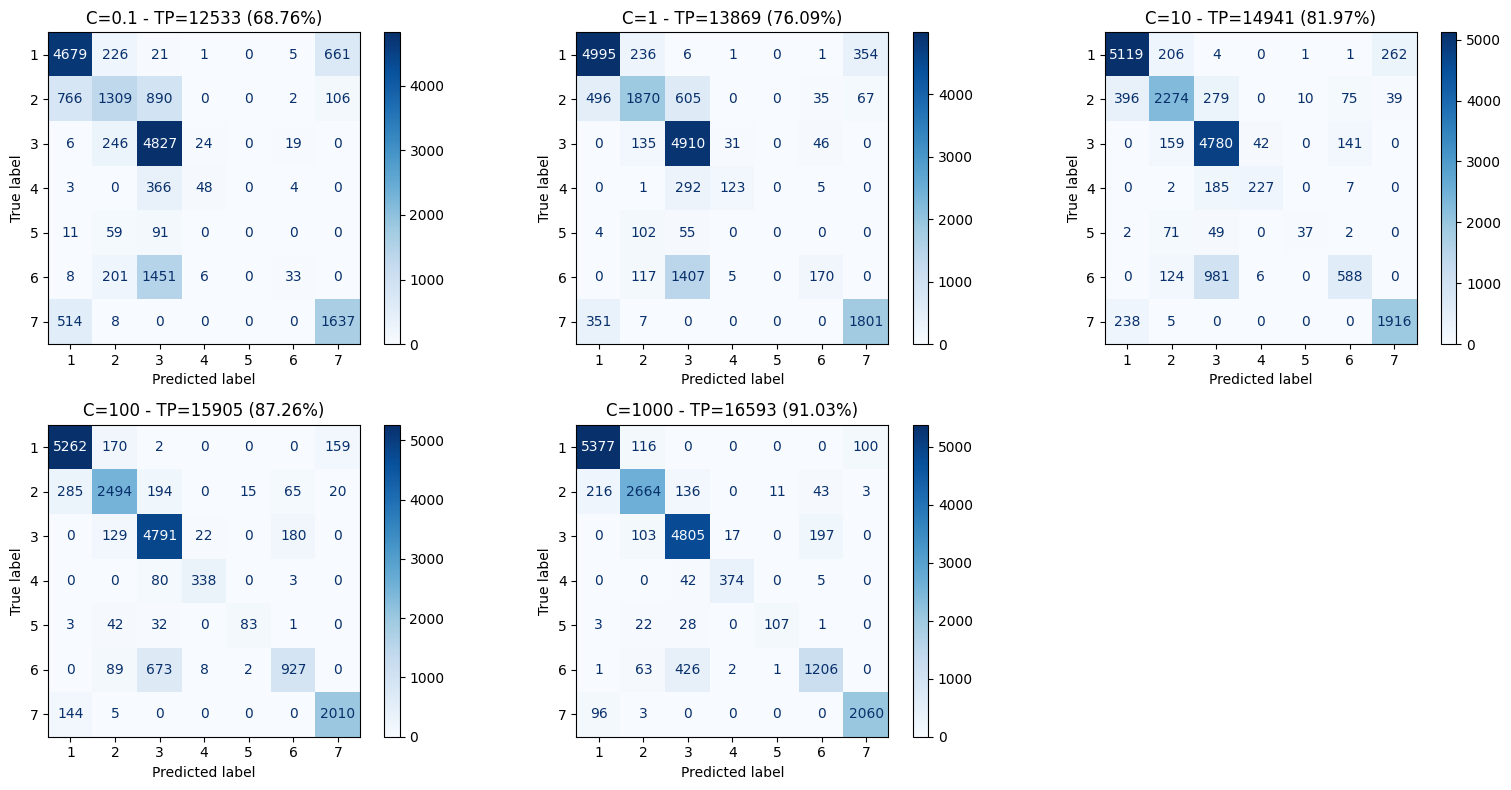

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, y_pred in enumerate(predictions):
    model = svc[i]
    cm = confusion_matrix(y_train, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues, ax=axes[i])
    accuracy_percentage = (cm.diagonal().sum() / len(y_train)) * 100
    title = f"C={model.C} - TP={cm.diagonal().sum()} ({accuracy_percentage:.2f}%)"
    axes[i].set_title(title)

for j in range(len(svc), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Ejemplos classificados correctamente C=0.1  - TP=12533 (68.76%)
- Ejemplos classificados correctamente C=1    - TP=13869 (76.09%)
- Ejemplos classificados correctamente C=10   - TP=14941 (81.97%)
- Ejemplos classificados correctamente C=100  - TP=15905 (87.26%)
- Ejemplos classificados correctamente C=1000 - TP=16593 (91.03%)


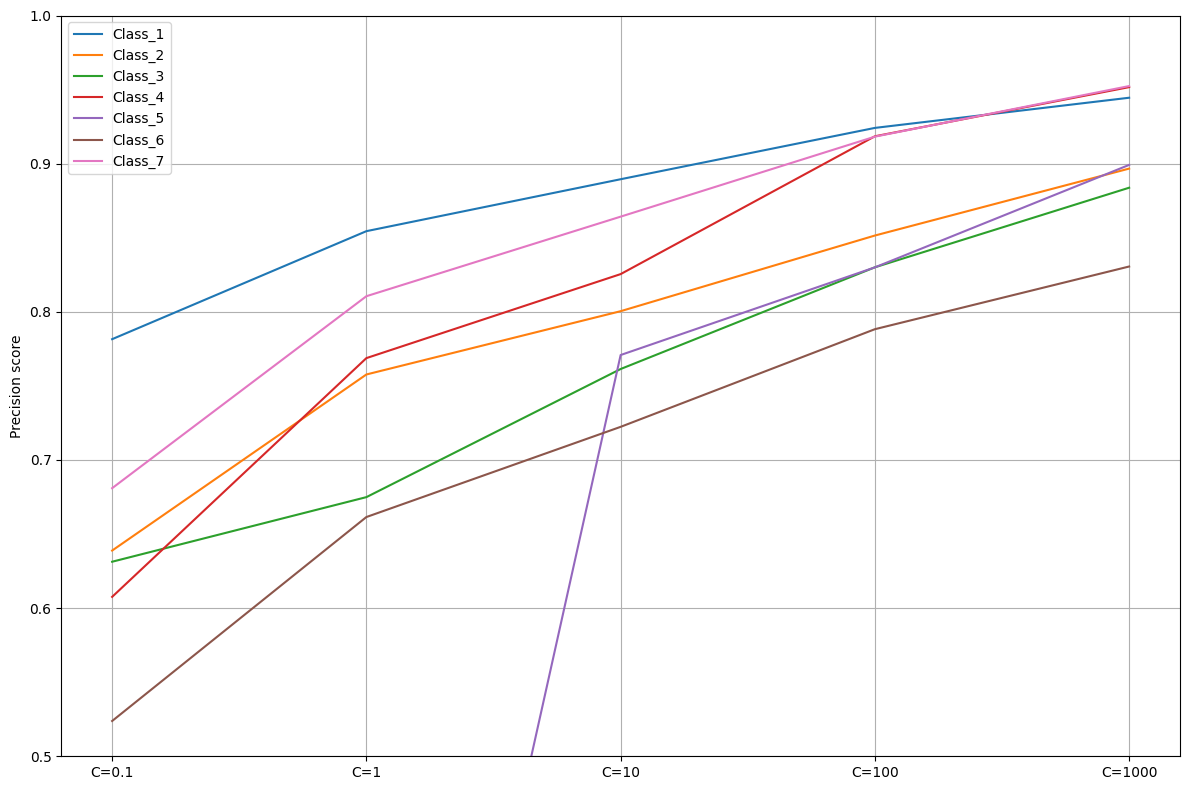

In [61]:
from sklearn.metrics import classification_report

reports = []
columns = []

for i, y_pred in enumerate(predictions):
    model = svc[i]
    report = classification_report(y_train, y_pred, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).transpose()
    reports.append(report_df['precision'])
    columns.append(model.C)

reports_df = pd.concat(reports, axis=1)
reports_df.columns = [f'C={col}' for col in columns]

plt.figure(figsize=(12, 8))
for i, row in reports_df.iterrows():
    if (len(i) == 1):
        plt.plot(reports_df.columns, row.values, label=f"Class_{i}")

plt.ylabel('Precision score')
plt.ylim(0.5, None)  # El eje Y comienza en 0.5, el límite superior será automático
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.show()

Para `C=1000`, se logra maximizar el valor de precision para todas las clases de `CoverType`, lo que lo convierte en el mejor modelo. Estos resultados indican que el modelo que aplica una penalización más alta a los errores (mayor valor de `C`) alcanza el mejor rendimiento general en términos de precisión.

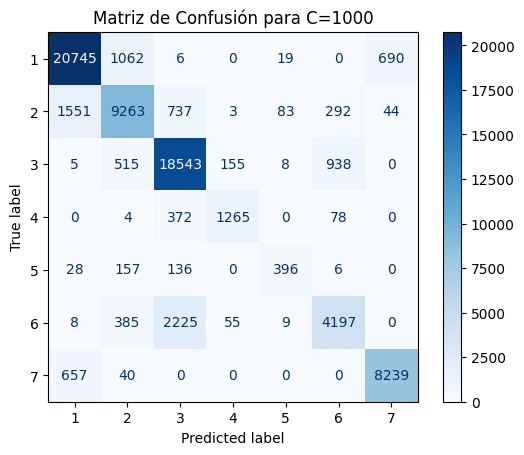

In [69]:
C=1000
y_pred_svm_test = None

for model in svc:
  if (C == model.C):
    y_pred_svm_test = model.predict(X_test_norm)
    cm = confusion_matrix(y_test, y_pred_svm_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matriz de Confusión para C={C}")
    plt.show()
    break

Matriz de confusión de los datos de test.

In [72]:
correct = cm.diagonal().sum()
print(f"Correctamente clasificados = {correct}")
print(f"Clasificados erróneamente = {len(X_test_norm) - correct}")

Correctamente clasificados = 62648
Clasificados erróneamente = 10268


              precision    recall  f1-score      support
1              0.902192  0.921099  0.911548  22522.00000
2              0.810695  0.773657  0.791743  11973.00000
3              0.842136  0.919609  0.879169  20164.00000
4              0.855886  0.735893  0.791367   1719.00000
5              0.768932  0.547718  0.639742    723.00000
6              0.761568  0.610118  0.677482   6879.00000
7              0.918199  0.922001  0.920096   8936.00000
accuracy       0.859180  0.859180  0.859180      0.85918
macro avg      0.837087  0.775728  0.801592  72916.00000
weighted avg   0.856842  0.859180  0.856359  72916.00000


- Clase con mejor rendimiento: 7 (F1-Score: 0.9201)
- Clase con peor rendimiento: 5 (F1-Score: 0.6397)




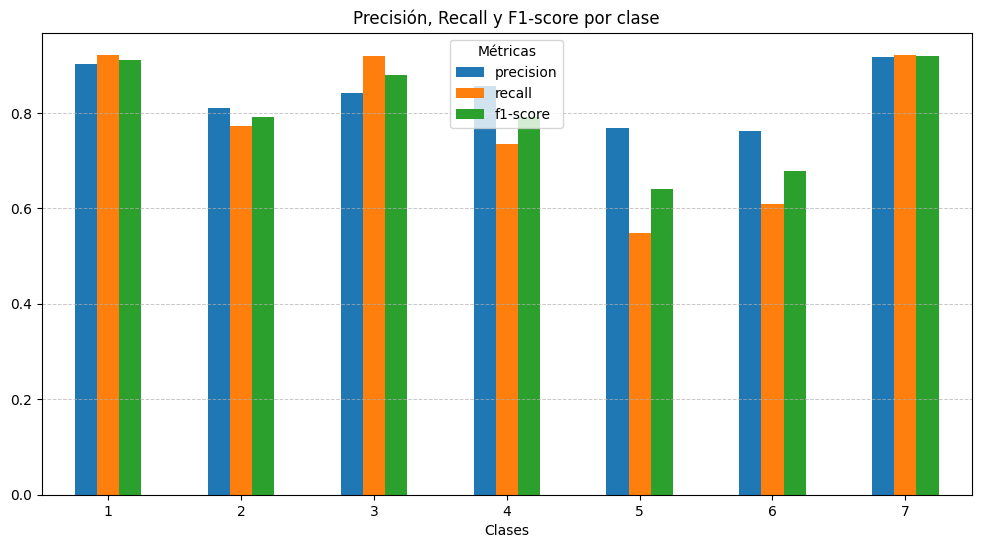

In [64]:
show_metrics_per_class(y_pred_svm_test)

**Comparativa**

¿Qué modelo obtiene mejores resultados de clasificación?

Ambos modelos tienen un rendimiento global similar (85.92% para SVM vs. 85.55% para Random Forest en accuracy).

Sin embargo, SVM obtiene un F1-Score ponderado ligeramente mayor (0.8564 frente a 0.8516).

En lo referente a la casificación de clases dominantes, vemos que SVM clasifica consistentemente bien las clases dominantes (1, 3, y 7), mientras que Random Forest muestra más variabilidad.

En cuanto a la clasificación de clases minoritarias, Random Forest clasifica mejor la clase 5, con un F1-Score: 0.7443 vs. 0.6397 en SVM. Aunque SVM tiene un mejor rendimiento general para la clase 6 (F1-Score: 0.6775 vs. 0.6456).

Random Forest, con 50 árboles, es más eficiente computacionalmente que SVM para conjuntos de datos grandes.